In [ ]:
from google.colab import files
uploaded = files.upload()

Saving imdb_data (1).csv to imdb_data (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [ ]:
df = pd.read_csv('imdb_data (1).csv')
df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [ ]:
# Remove movies with zero budget
df = df[df['budget'] > 0]

# Create Profit & ROI
df['profit'] = df['revenue'] - df['budget']
df['ROI'] = df['profit'] / df['budget']

In [ ]:
# Director
def get_director(crew):
    try:
        crew_list = ast.literal_eval(crew)
        for person in crew_list:
            if person['job'] == 'Director':
                return person['name']
    except:
        return None

# Producer
def get_producer(crew):
    try:
        crew_list = ast.literal_eval(crew)
        for person in crew_list:
            if person['job'] == 'Producer':
                return person['name']
    except:
        return None

# Actors
def get_actors(cast):
    try:
        cast_list = ast.literal_eval(cast)
        return [actor['name'] for actor in cast_list]
    except:
        return []

df['director'] = df['crew'].apply(get_director)
df['producer'] = df['crew'].apply(get_producer)
df['actors'] = df['cast'].apply(get_actors)

# Remove empty actor rows
df = df[df['actors'].map(len) > 0]

In [ ]:
max_movie = df.loc[df['profit'].idxmax()]

print("Title:", max_movie['title'])
print("Director:", max_movie['director'])
print("Producer:", max_movie['producer'])
print("Actors:", max_movie['actors'][:3])
print("Profit:", max_movie['profit'])

Title: Furious 7
Director: James Wan
Producer: Vin Diesel
Actors: ['Vin Diesel', 'Paul Walker', 'Dwayne Johnson']
Profit: 1316249360


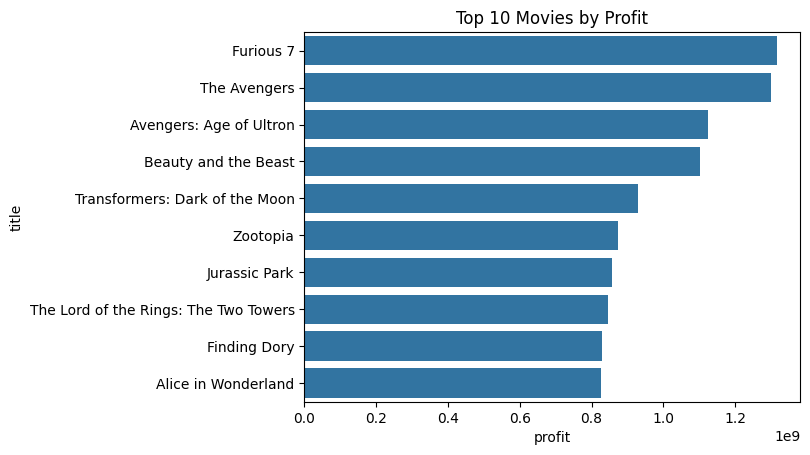

In [ ]:
top_movies = df.sort_values(by='profit', ascending=False).head(10)

plt.figure()
sns.barplot(x=top_movies['profit'], y=top_movies['title'])
plt.title("Top 10 Movies by Profit")
plt.show()

In [ ]:
lang_roi = df.groupby('original_language')['ROI'].mean().sort_values(ascending=False)
print(lang_roi.head())

original_language
ko    381794.102281
en      5482.165566
el        51.980132
tr         9.660000
he         4.562925
Name: ROI, dtype: float64


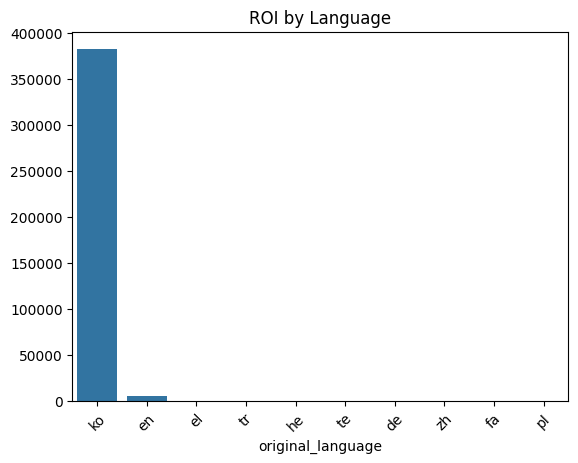

In [ ]:
plt.figure()
sns.barplot(x=lang_roi.head(10).index, y=lang_roi.head(10).values)
plt.xticks(rotation=45)
plt.title("ROI by Language")
plt.show()

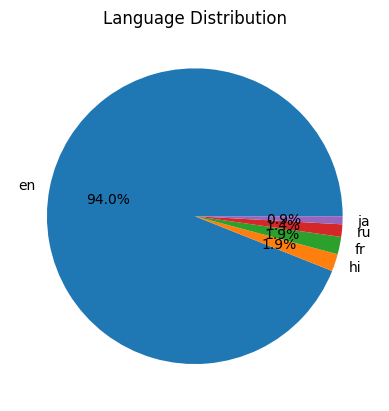

In [ ]:
lang_count = df['original_language'].value_counts().head(5)

plt.figure()
plt.pie(lang_count.values, labels=lang_count.index, autopct='%1.1f%%')
plt.title("Language Distribution")
plt.show()

In [ ]:
genres = set()

for g in df['genres'].dropna():
    try:
        g_list = ast.literal_eval(g)
        for item in g_list:
            genres.add(item['name'])
    except:
        pass

print(genres)

{'Fantasy', 'Comedy', 'Music', 'Documentary', 'Romance', 'Adventure', 'TV Movie', 'Science Fiction', 'Western', 'Foreign', 'Mystery', 'Animation', 'Family', 'History', 'Horror', 'Thriller', 'Crime', 'Action', 'War', 'Drama'}


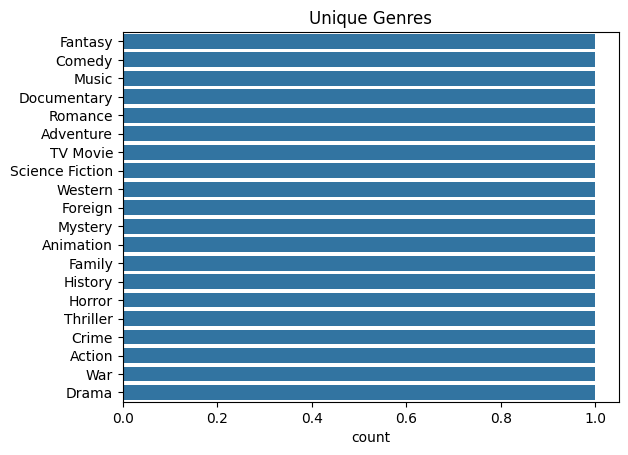

In [ ]:
genre_list = list(genres)

plt.figure()
sns.countplot(y=genre_list)
plt.title("Unique Genres")
plt.show()

In [ ]:
print(df[['title','producer','director']].head())

top_producers = df.groupby('producer')['ROI'].mean().sort_values(ascending=False).head(3)
print(top_producers)

                                      title         producer         director
0                    Hot Tub Time Machine 2     Andrew Panay       Steve Pink
1  The Princess Diaries 2: Royal Engagement  Whitney Houston   Garry Marshall
2                                  Whiplash  David Lancaster  Damien Chazelle
3                                   Kahaani      Sujoy Ghosh      Sujoy Ghosh
5    Pinocchio and the Emperor of the Night             None   Hal Sutherland
producer
Jang Jin           4197475.625
Charlie Chaplin    2833337.500
Marc Bienstock      999999.000
Name: ROI, dtype: float64


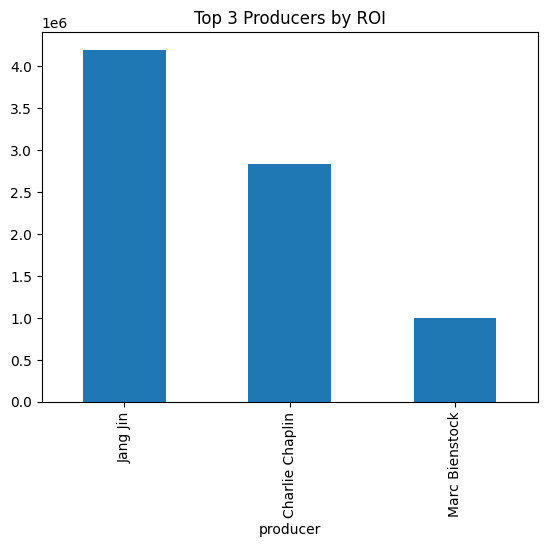

In [ ]:
top_producers.plot(kind='bar')
plt.title("Top 3 Producers by ROI")
plt.show()

In [ ]:
all_actors = df['actors'].explode()

top_actor = all_actors.value_counts().idxmax()
print("Top Actor:", top_actor)

actor_movies = df[df['actors'].apply(lambda x: top_actor in x)]
print(actor_movies[['title','profit']])

Top Actor: Samuel L. Jackson
                                             title      profit
29                                  Changing Lanes    49935764
47                               The Hateful Eight   111760117
642                              Coming to America   249752301
689   Star Wars: Episode III - Revenge of the Sith   737000000
1126                                  The Avengers  1299557910
1181                                        Jumper   137231186
1426                                         Shaft    61196498
1482                             Snakes on a Plane    29022014
1717                                       RoboCop   122688965
1735                                 Jurassic Park   857100000
1818  Star Wars: Episode II - Attack of the Clones   529398328
1861           Captain America: The Winter Soldier   544766572
1916                                  Jackie Brown    27673162
1970                                      Big Game    -1000000
2214                      

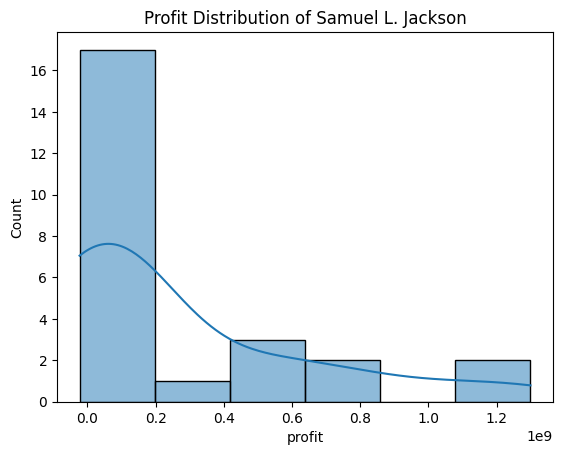

In [ ]:
sns.histplot(actor_movies['profit'], kde=True)
plt.title(f"Profit Distribution of {top_actor}")
plt.show()

In [ ]:
top_directors = df['director'].value_counts().head(3).index

for director in top_directors:
    subset = df[df['director'] == director]
    actors = subset['actors'].explode()

    print(director)
    print(actors.value_counts().head(1))

Steven Spielberg
actors
Harrison Ford    3
Name: count, dtype: int64
Clint Eastwood
actors
Clint Eastwood    6
Name: count, dtype: int64
Ron Howard
actors
Clint Howard    4
Name: count, dtype: int64


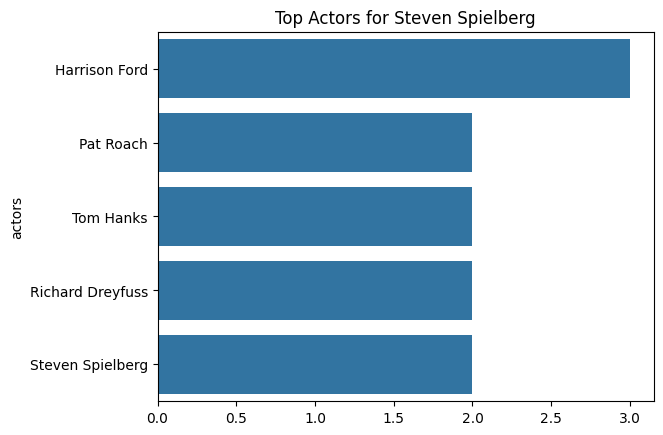

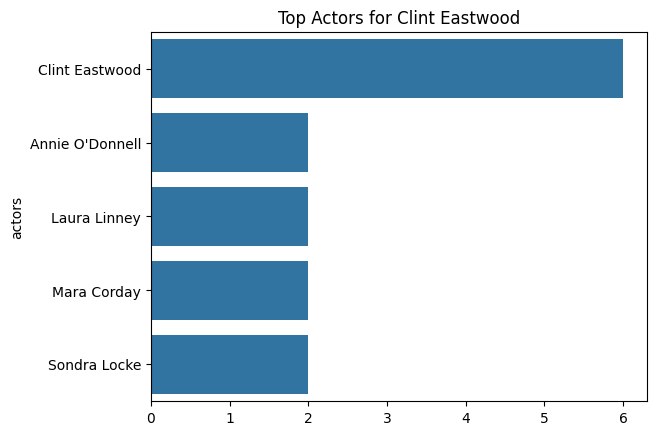

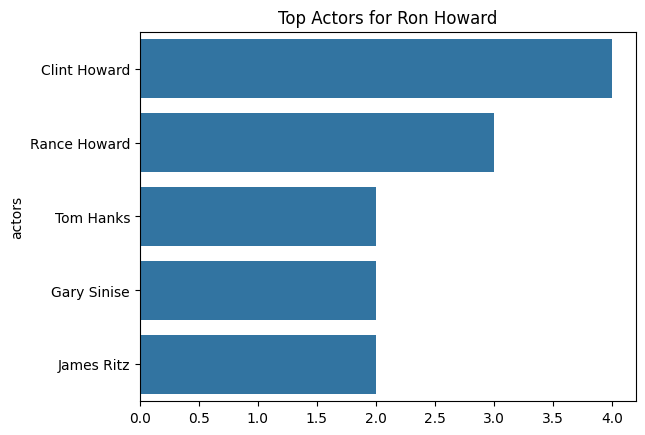

In [ ]:
for director in top_directors:
    subset = df[df['director'] == director]
    actors = subset['actors'].explode().value_counts().head(5)

    plt.figure()
    sns.barplot(x=actors.values, y=actors.index)
    plt.title(f"Top Actors for {director}")
    plt.show()